In [21]:
import pandas as pd
from pathlib import Path

PROCESSED = Path("../data/processed")

fact = pd.read_csv(PROCESSED / "fact_exported.csv")

fact.head()

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,usd_brl,VL_FOB_BRL
0,2021,1,40169990,10,361,SP,1,817800,5353,5353,42235,5.356245,226221.007575
1,2021,2,94035000,11,317,RS,1,1017700,487,49670,53961,5.416494,292279.456717
2,2021,11,35051000,10,63,MG,7,1017500,144000,144000,99654,5.556860,553763.326440
3,2021,4,61023000,11,249,SP,4,817600,14,5,1087,5.562135,6046.040745
4,2021,2,82111000,11,63,RS,7,1017503,7708,1105,12488,5.416494,67641.182622


In [22]:
fact.groupby("CO_ANO")["VL_FOB"].sum()

CO_ANO
2021    280814577460
2022    334136038220
2023    339695766008
2024    337046161710
2025    348278462500
Name: VL_FOB, dtype: int64

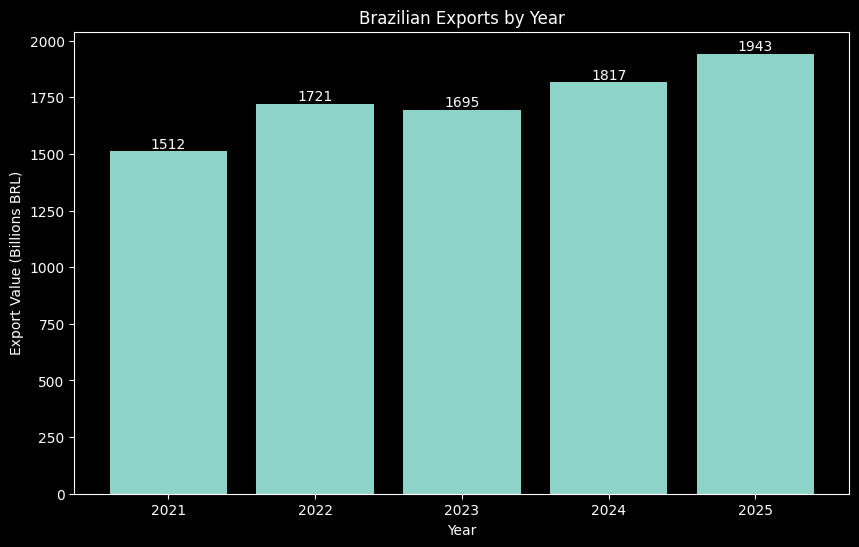

In [24]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")

exports = fact.groupby("CO_ANO")["VL_FOB_BRL"].sum() / 1e9

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(exports.index.astype(str), exports.values)

ax.set_title("Brazilian Exports by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (Billions BRL)")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.0f}",
        ha='center',
        va='bottom'
    )

plt.show()